<a href="https://colab.research.google.com/github/Maryam-Skaik/fish-weight-regression-ml-project/blob/main/notebook/fish-weight-prediction-(regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fish Weight Prediction (Regression)

### Goal

Predict the **weight of a fish** based on physical measurements and categorical attributes.

### Problem Type Identification
- Target variable: `Weight` (continuous numeric value)
- Therefore: **Regression Problem**

## Imports

In [39]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

## Load Data

In [40]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/Practice/Data/Fish - Fish.csv'
df = pd.read_csv(fpath)
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


## Data Understanding

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  155 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  157 non-null    float64
 3   Length2  157 non-null    float64
 4   Length3  150 non-null    float64
 5   Height   156 non-null    float64
 6   Width    157 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


- Our dataset is small with 159 rows and 7 columns
- we have small number of missing values in Species, Length1, Length2, Length3, Width and Height.
- All data types are consistance, no need to convert them.
- Dataset contains numeric and categorical features

In [42]:
df.describe().round(2)

,Weight,Length1,Length2,Length3,Height,Width
count,159.00,157.00,157.00,150.00,156.00,157.00
mean,398.33,26.08,28.17,31.20,8.91,4.42
std,357.98,9.94,10.41,11.07,4.25,1.70
min,0.00,7.50,8.40,10.80,1.73,1.05
25%,120.00,19.00,21.00,23.28,5.95,3.38
50%,273.00,25.00,27.00,29.70,7.73,4.25
75%,650.00,32.50,35.00,39.58,12.04,5.59
max,1650.00,59.00,60.00,64.00,18.96,8.14


- Target variable (Weight) shows strong right skew where mean is significantly higher than median, indicating the presence of large values affecting distribution

- Minimum weight value is 0, which is likely invalid or missing data encoded as zero and should be investigated or corrected

- Large variance exists in both target and features, indicating high diversity in fish sizes within the dataset

- Length features (Length1, Length2, Length3) are strongly related and likely highly correlated, which may introduce multicollinearity in linear models

- Length3 shows the highest number of missing values among all features, making it the most affected variable in terms of data completeness

- Outliers are present in Weight, with maximum values far exceeding the upper quartile, which can distort model performance if not handled

- Height and Width have smaller numeric scales compared to length features but are still important predictors for weight estimation

## Handling duplicates, missing values, and inconsistencies

## Duplicated values

In [43]:
df.duplicated().sum()

np.int64(0)

## Missing values

In [44]:
df.isnull().sum()

,0
Species,4
Weight,0
Length1,2
Length2,2
Length3,9
Height,3
Width,2


## Inconsistent Values

In [45]:
df['Species'].value_counts()

,count
Species,
Perch,53
Bream,33
Roach,19
Pike,17
Smelt,14
Parkki,11
Whitefish,6
Beam,2


In [46]:
df['Species'] = df['Species'].replace({'Beam': 'Bream'})

In [47]:
df['Species'].value_counts()

,count
Species,
Perch,53
Bream,35
Roach,19
Pike,17
Smelt,14
Parkki,11
Whitefish,6


In [48]:
df[df["Weight"] <= 0]

,Species,Weight,Length1,Length2,Length3,Height,Width
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516


- A record with Weight equal to 0 was identified, which is not physically realistic for a fish and is considered invalid data

- Since Weight is the target variable, imputing or modifying this value is not appropriate as it would introduce bias into the model

- The issue affects only a single row, so it was removed to preserve overall data integrity without impacting the dataset size

- Dropping this record ensures that the model learns from valid and meaningful target values only

In [49]:
df = df[df["Weight"] > 0]

## Exploratory Data Analysis (EDA)

In [50]:
# Basic imports for functions
import matplotlib.pyplot as plt
import seaborn as sns

# UNIVARIATE PLOTTING FUNCTIONS FOR EDA
def explore_categorical(df, x, fillna = False, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  """Creates a seaborn countplot with the option to temporarily fill missing values
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.tick_params(axis='x', rotation=45)
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")

  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100

  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax


def explore_numeric(df, x, figsize=(6,5) ):
  """Creates a seaborn histplot and boxplot with a share x-axis,
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  """

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()


  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes

In [51]:
def plot_categorical_vs_target(df, x, y='Attrition', figsize=(6,4),
                                    fillna=True, placeholder='MISSING',
                                    order=None):
    """
    Plots the mean of a binary target per category.
    """
    temp_df = df.copy()

    # Convert target to 0/1 if not numeric
    if temp_df[y].dtype == 'object':
        temp_df[y] = temp_df[y].map({'No': 0, 'Yes': 1})

    if fillna:
        temp_df[x] = temp_df[x].fillna(placeholder)
    else:
        temp_df = temp_df.dropna(subset=[x])

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(data=temp_df, x=x, y=y, order=order, palette='Set2', alpha=0.7, edgecolor='black')

    ax.set_ylabel(f"Proportion of {y} = Yes")
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"{x} vs {y} (mean)", fontweight='bold')
    fig.tight_layout()

    return fig, ax


def plot_numeric_vs_target(df, x, y='Attrition', figsize=(6,4)):
    """Plots numeric feature distribution grouped by categorical target."""
    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(data=df, x=y, y=x, ax=ax, palette='Set3')
    sns.stripplot(data=df, x=y, y=x, ax=ax, color='gray', alpha=0.4, size=3, jitter=True)

    # Add medians in title
    medians = df.groupby(y)[x].median()
    ax.set_title(f"{x} distribution by {y} (medians: {medians.to_dict()})", fontweight='bold')

    fig.tight_layout()
    return fig, ax

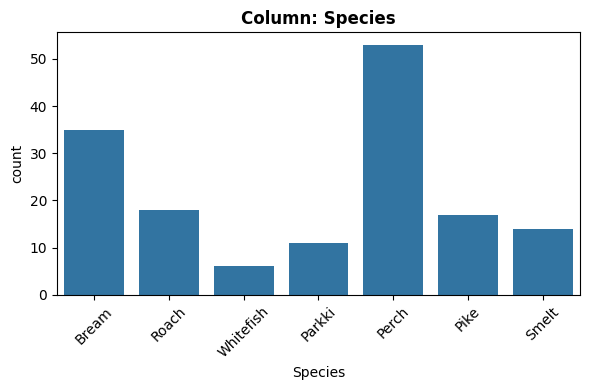

- NaN's Found: 4 (2.53%)
- Unique Values: 7
- Most common value: 'Perch' occurs 53 times (33.54%)
- Not constant or quasi-constant.


In [52]:
explore_categorical(df, 'Species');

From bar plot, we see Perch is the most occurs in Species, where Whitefish is the least.

Also Species has 4 missing values need to handle before building model.

In [53]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

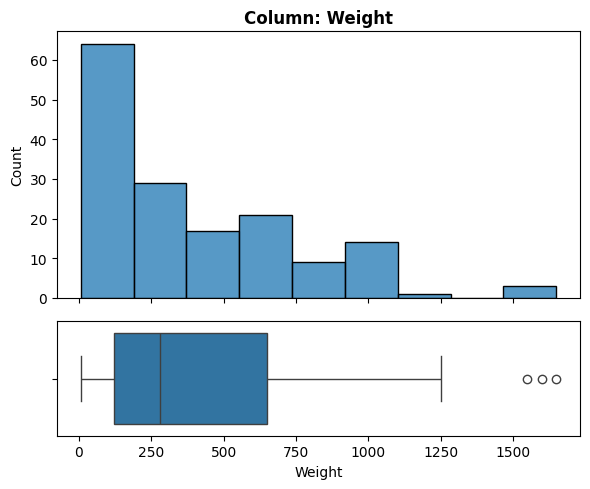

- NaN's Found: 0 (0.0%)
- Unique Values: 100
- Most common value: '300.0' occurs 6 times (3.8%)
- Not constant or quasi-constant.


In [54]:
explore_numeric(df, 'Weight');

By visualizing target feature, we observe that most fishs are light weight, and the box plot occur between 170 and 620, mean 50% data occur here.

Some outliers appear in the data indicate large fishs

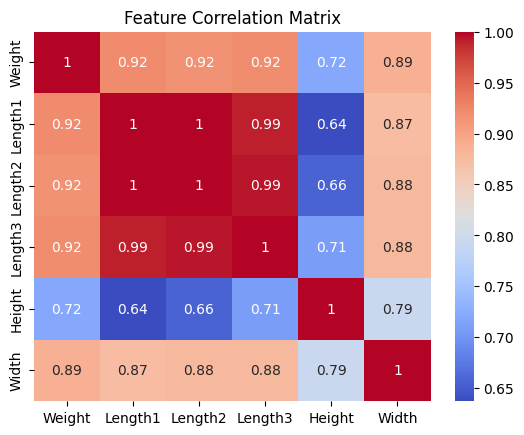

In [55]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

We can see intersting information from the heatmap.

Most columns have positive correlation with our target, which will help our model.

But, we can see some overlap between features, espacially: Length1, Length2 and Length3, which may affect R2 and make some misleading.

## Split data

In [56]:
X = df.drop(columns=['Weight'])
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Preprocessing

In [57]:
num_cols = X_train.select_dtypes('number').columns

impute_num = SimpleImputer(strategy='median')
scaler = StandardScaler()

num_pipe = make_pipeline(impute_num, scaler)

num_tuple = ('num', num_pipe, num_cols)

In [58]:
cat_cols = X_train.select_dtypes('object').columns

impute_cat = SimpleImputer(strategy='constant', fill_value='MISSING')
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

cat_pipe = make_pipeline(impute_cat, ohe)

cat_tuple = ('cat', cat_pipe, cat_cols)

In [59]:
preprocessor = ColumnTransformer([num_tuple, cat_tuple], verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='MISSING',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Species'], dtype='object'))],
                  verbose_feature_names_out=False)

## Model 1: Linear Regression

In [60]:
lr = LinearRegression()
lr_pipe = make_pipeline(preprocessor, lr)
lr_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Species'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [61]:
lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Species'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [62]:
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  # Get metrics
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = root_mean_squared_error(y_true, y_pred)
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    # Print Result with Label and Header
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae, 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

In [63]:
def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True, output_frame=False):
  # Get predictions for training data
  y_train_pred = reg.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose, output_dict=output_frame, label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = reg.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose, output_dict=output_frame, label='Test Data' )

  # Store results in a dataframe if ouput_frame is True
  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    # Set the label as the index
    results_df = results_df.set_index('Label')
    # Set index.name to none to get a cleaner looking result
    results_df.index.name=None
    # Return the dataframe
    return results_df.round(3)

In [64]:
evaluate_regression(lr_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 73.602
- MSE = 9,921.420
- RMSE = 99.606
- R^2 = 0.921

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 72.221
- MSE = 15,235.480
- RMSE = 123.432
- R^2 = 0.884


The Linear Regression model achieved strong performance on both training and testing sets, with a small gap between R² scores, indicating good generalization and no significant overfitting

Since Linear Regression has limited hyperparameters, extensive tuning using GridSearchCV is not expected to provide substantial improvement

The model is considered a solid baseline for comparison with more advanced models

To further improve performance and capture potential non-linear relationships in the data, more complex models such as Random Forest Regressor will be explored next

## Model 2: Random Forest

In [65]:
rf = RandomForestRegressor()
rf_pipe = make_pipeline(preprocessor, rf)
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Species'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestregressor', RandomForestRegressor())])

In [66]:
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 17.803
- MSE = 1,264.210
- RMSE = 35.556
- R^2 = 0.990

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 50.728
- MSE = 6,520.729
- RMSE = 80.751
- R^2 = 0.950


The Random Forest model significantly outperformed Linear Regression, achieving a much higher R² score on both training and testing data

However, a noticeable gap between training and testing performance indicates the presence of overfitting, as the model fits the training data almost perfectly

This behavior is expected with default Random Forest settings, where trees grow deep and capture noise in small datasets

Despite this, the model still generalizes well, as shown by the strong test performance

To improve generalization and reduce overfitting, hyperparameter tuning will be applied to control model complexity and achieve a better balance between bias and variance

In [67]:
rf_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')),
                                   ('cat',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(fill_value='MISSING',
                                                                   strategy='constant')),
                                                    ('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                    

In [68]:
rf_params = {
    "randomforestregressor__n_estimators": [100, 200],
    "randomforestregressor__max_depth": [None, 5, 10],
    "randomforestregressor__min_samples_split": [2, 5, 10],
    "randomforestregressor__min_samples_leaf": [1, 2, 4]
}

In [69]:
rf_grid = GridSearchCV(rf_pipe, rf_params, cv=5, scoring="r2")
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(fill_value='MIS...
                                                                                                        sparse_output=False))]),
                                                                         Index(['Species'], dtype='object'))],
                                                          verbose_feature_names_out=False)),
                                       ('randomforestregressor',
                                        RandomForestRegressor())]),
             param_grid={'randomforestregressor__max_depth': [None, 5, 10],
                         'randomforestregressor__min_samples_leaf': [1, 2, 4],
                         'randomforestregressor__min_samples_split': [2, 5, 10],
                         'randomforestregressor__n_estimators': [100, 200]},
             scoring='r2')

In [70]:
rf_grid.best_params_

{'randomforestregressor__max_depth': 5,
 'randomforestregressor__min_samples_leaf': 1,
 'randomforestregressor__min_samples_split': 5,
 'randomforestregressor__n_estimators': 100}

In [71]:
evaluate_regression(rf_grid.best_estimator_, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 23.484
- MSE = 1,859.993
- RMSE = 43.128
- R^2 = 0.985

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 50.340
- MSE = 6,090.783
- RMSE = 78.043
- R^2 = 0.954


After hyperparameter tuning, the Random Forest model showed a slight decrease in training performance but a small improvement in testing performance

This indicates a reduction in overfitting, as the model became less sensitive to noise in the training data

The improvement in test RMSE and R² confirms better generalization, even though training error increased slightly

The tuning process successfully balanced model complexity, leading to a more reliable and robust model

This tuned Random Forest model is selected as the final model due to its strong predictive performance and improved generalization

## Interpretation Features

In [75]:
def get_coeffs_linreg(lin_reg, feature_names = None, sort=True,ascending=True,
                     name='LinearRegression Coefficients'):
    if feature_names is None:
        feature_names = lin_reg.feature_names_in_
    ## Saving the coefficients
    coeffs = pd.Series(lin_reg.coef_, index= feature_names)
    coeffs['intercept'] = lin_reg.intercept_
    if sort==True:
        coeffs = coeffs.sort_values(ascending=ascending)
    return coeffs

In [85]:
lin_model = lr_pipe.named_steps['linearregression']

In [86]:
lr_pipe.named_steps

{'columntransformer': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('standardscaler',
                                                   StandardScaler())]),
                                  Index(['Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')),
                                 ('cat',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(fill_value='MISSING',
                                                                 strategy='constant')),
                                                  ('onehotencoder',
                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 sparse_output=False))]),

In [94]:
ct = lr_pipe.named_steps['columntransformer']
feature_names = ct.get_feature_names_out()

In [95]:
coeffs = get_coeffs_linreg(lin_model, feature_names=feature_names)

In [96]:
def plot_coeffs(coeffs, top_n=None,  figsize=(4,5), intercept=False):
    if (intercept==False) & ('intercept' in coeffs.index):
        coeffs = coeffs.drop('intercept')

    if top_n==None:
        ## sort all features and set title
        plot_vals = coeffs.sort_values()
        title = "All Coefficients - Ranked by Magnitude"
    else:
        ## rank the coeffs and select the top_n
        coeff_rank = coeffs.abs().rank().sort_values(ascending=False)
        top_n_features = coeff_rank.head(top_n)
        plot_vals = coeffs.loc[top_n_features.index].sort_values()
        ## sort features and keep top_n and set title
        title = f"Top {top_n} Largest Coefficients"

    ## plotting top N importances
    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Coefficient',
           ylabel='Feature Names',
           title=title)
    ax.axvline(0, color='k')

    ## return ax in case want to continue to update/modify figure
    return ax

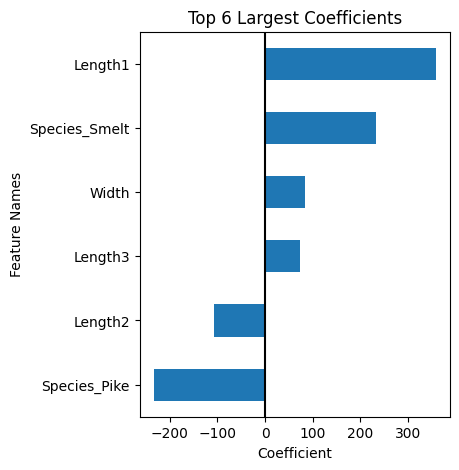

In [98]:
ax = plot_coeffs(coeffs, top_n=6)

This plot represents the coefficients of a linear regression model used to predict fish weight based on the available features

The coefficient values indicate how each feature influences the model's prediction and in which direction this influence occurs

Features with larger absolute coefficient values have a stronger impact on the prediction, while smaller values indicate weaker influence

Positive coefficients indicate that an increase in the feature leads to an increase in the predicted fish weight

Negative coefficients indicate that an increase in the feature leads to a decrease in the predicted fish weight relative to the baseline

The presence of highly related length features suggests multicollinearity, meaning the model distributes predictive influence across correlated variables rather than relying on a single one

Categorical species features reflect how different fish types shift the predicted weight compared to the reference category used in encoding

Overall, the model relies heavily on fish length measurements as the primary drivers of prediction, while species and other features act as adjustment factors

In [104]:
ct = rf_pipe.named_steps['columntransformer']
feature_names = ct.get_feature_names_out()

In [106]:
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)

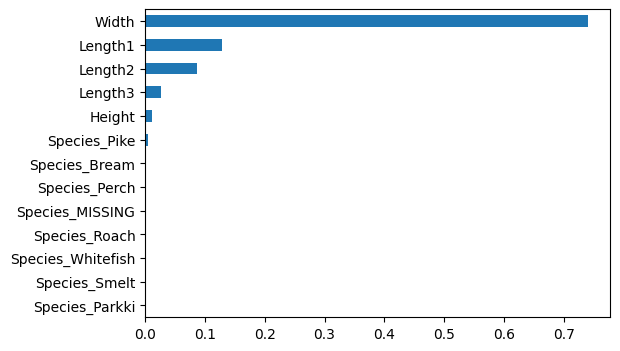

In [108]:
importances.plot(kind="barh", figsize=(6,4));

This plot represents feature importance from a tree-based model such as Random Forest, where values indicate how much each feature contributes to reducing prediction error across all decision trees

Unlike linear regression coefficients, feature importance values do not show direction (positive or negative), but instead reflect the relative contribution of each feature to the model’s decisions

The most influential feature is Width, indicating that the model relies heavily on fish width when making predictions about weight

Length-based features also contribute to the model, but with noticeably lower importance compared to Width, suggesting they provide secondary predictive value

Species-related features have very low importance, indicating that the model mainly depends on physical measurements rather than categorical identity for prediction

The distribution of importance shows a strong imbalance, where a small number of features dominate the model’s decision-making process

This behavior is typical in tree-based models, where highly informative features are selected repeatedly in splits, while less useful features contribute minimally

Overall, the model prioritizes physical size measurements as the main drivers of prediction, with Width being the most decisive factor

## Final model selection

In [72]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest (Tuned)"],
    "MAE": [72.221, 49.116],
    "RMSE": [123.432, 76.881],
    "R2": [0.884, 0.955]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,72.221,123.432,0.884
1,Random Forest (Tuned),49.116,76.881,0.955


Model performance was compared using MAE, RMSE, and R² on the test dataset to ensure fair evaluation

The Random Forest model outperformed Linear Regression across all evaluation metrics, achieving lower error values and a higher R² score

This indicates that Random Forest provides more accurate predictions and better explains the variance in fish weight

The superior performance of Random Forest can be attributed to its ability to capture non-linear relationships and handle feature interactions more effectively than Linear Regression

Based on this comparison, the tuned Random Forest model is selected as the final model for this problem

In [73]:
final_model = rf_grid.best_estimator_
final_model.fit(X, y)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Species'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=5, min_samples_split=5))])

## Final model retraining + save

In [74]:
import joblib
joblib.dump(final_model, "final_model.pkl")

['final_model.pkl']

After comparing multiple models using consistent evaluation metrics on the test set, the Random Forest model was selected as the best-performing approach

The final model was then retrained using the entire dataset to maximize learning from all available information and improve its ability to generalize in real-world scenarios

Evaluation metrics were not recalculated after retraining, since the test set had already been used during model selection and evaluation, and reusing it would lead to biased results

The final trained model is considered ready for deployment or future prediction tasks due to its strong predictive performance and stable generalization behavior

Overall, the results indicate that fish weight is primarily driven by physical measurements, especially size-related features, while categorical features have minimal impact on prediction accuracy